In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
# =========================
# 1) Load data
# =========================
ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw"

riders = pd.read_csv(RAW / "riders.csv")
trips  = pd.read_csv(RAW / "trips.csv")

print("Loaded ✅")
print("riders:", riders.shape)
print("trips :", trips.shape)

Loaded ✅
riders: (10000, 8)
trips : (200000, 16)


In [3]:
# =========================
# 2) Minimal cleaning + datatypes
# =========================
# Dates
riders["signup_date"] = pd.to_datetime(riders.get("signup_date"), errors="coerce")

# Detect trip datetime column (pickup_time is common in your dataset)
trip_dt_col = None
for c in ["pickup_time", "dropoff_time", "trip_time", "trip_date", "start_time", "created_at"]:
    if c in trips.columns:
        trips[c] = pd.to_datetime(trips[c], errors="coerce")
        if trips[c].notna().mean() > 0.60:
            trip_dt_col = c
            break

print("Trip datetime column:", trip_dt_col)

# Convert object columns to string (optional but helps consistency)
def convert_objects_to_string(df):
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = df[obj_cols].astype("string")
    return df

riders = convert_objects_to_string(riders)
trips  = convert_objects_to_string(trips)

C:\Users\Admin\AppData\Local\Temp\ipykernel_17248\2509995070.py:11: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips[c] = pd.to_datetime(trips[c], errors="coerce")


Trip datetime column: pickup_time


In [4]:
# =========================
# 3) Rider-level feature engineering
# =========================
as_of = riders["signup_date"].max()
if pd.isna(as_of):
    as_of = pd.Timestamp.today().normalize()

riders["tenure_days"] = (as_of - riders["signup_date"]).dt.days

# Referral feature (keep it for segmentation)
if "referred_by" in riders.columns:
    riders["was_referred"] = riders["referred_by"].notna().astype(int)
else:
    riders["was_referred"] = 0

# Loyalty feature
if "loyalty_status" in riders.columns:
    riders["is_loyalty_member"] = riders["loyalty_status"].astype(str).str.lower().isin(
        ["yes", "true", "1", "member", "gold", "silver"]
    ).astype(int)
else:
    riders["is_loyalty_member"] = 0

# Age band (optional)
if "age" in riders.columns:
    riders["age_band"] = pd.cut(
        riders["age"],
        bins=[0, 18, 25, 35, 45, 55, 65, 120],
        labels=["<18","18-24","25-34","35-44","45-54","55-64","65+"],
        right=False
    )

In [6]:
# =========================
# 4) Trip-level aggregation to user level
# =========================

if "user_id" not in trips.columns:
    raise ValueError("Trips must include user_id. Your trips.csv is missing user_id.")

agg_dict = {
    "total_trips": ("user_id", "size"),
}

# Add numeric aggregations ONLY if those columns exist
if "fare" in trips.columns:
    agg_dict["avg_fare"] = ("fare", "mean")
    agg_dict["total_spent"] = ("fare", "sum")
    agg_dict["max_fare"] = ("fare", "max")

if "tip" in trips.columns:
    agg_dict["avg_tip"] = ("tip", "mean")
    agg_dict["total_tip"] = ("tip", "sum")

if "surge_multiplier" in trips.columns:
    agg_dict["avg_surge"] = ("surge_multiplier", "mean")
    agg_dict["max_surge"] = ("surge_multiplier", "max")

# Aggregate trips
trip_agg = trips.groupby("user_id").agg(**agg_dict).reset_index()

In [8]:
# =========================
# Recency (if datetime exists)
# =========================
if trip_dt_col is not None:

    # Ensure trip datetime column is datetime
    trips[trip_dt_col] = pd.to_datetime(trips[trip_dt_col], errors="coerce")

    # Get last trip per user
    last_trip = trips.groupby("user_id")[trip_dt_col].max().reset_index()
    last_trip.columns = ["user_id", "last_trip_date"]

    # Merge into trip_agg
    trip_agg = trip_agg.merge(last_trip, on="user_id", how="left")

    # Ensure last_trip_date is datetime
    trip_agg["last_trip_date"] = pd.to_datetime(
        trip_agg["last_trip_date"], errors="coerce"
    )

    # Ensure as_of is datetime
    as_of = pd.to_datetime(as_of, errors="coerce")

    # Remove timezone if present (safe operation)
    if trip_agg["last_trip_date"].dt.tz is not None:
        trip_agg["last_trip_date"] = trip_agg["last_trip_date"].dt.tz_localize(None)

    # Calculate recency
    trip_agg["recency_days"] = (
        as_of - trip_agg["last_trip_date"]
    ).dt.days

    # Optional: if user never took a trip, treat as very inactive
    trip_agg["recency_days"] = trip_agg["recency_days"].fillna(
        trip_agg["recency_days"].max() + 1
    )

print("Trip aggregation complete ✅")
print(trip_agg.shape)
display(trip_agg.head())


C:\Users\Admin\AppData\Local\Temp\ipykernel_17248\715150789.py:7: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  trips[trip_dt_col] = pd.to_datetime(trips[trip_dt_col], errors="coerce")


Trip aggregation complete ✅
(10000, 11)


,user_id,total_trips,avg_fare,total_spent,max_fare,avg_tip,total_tip,avg_surge,max_surge,last_trip_date,recency_days
0,R00000,25,14.642000,366.05,23.62,0.161200,4.03,1.096000,1.6,2025-04-02 17:13:29,23.0
1,R00001,14,12.895000,180.53,18.01,0.054286,0.76,1.071429,1.8,2025-04-22 07:02:17,3.0
2,R00002,24,15.791250,378.99,33.26,0.217083,5.21,1.191667,2.1,NaT,131.0
3,R00003,9,13.496667,121.47,23.98,0.096667,0.87,1.155556,1.6,2025-02-25 06:49:32,59.0
4,R00004,16,16.776875,268.43,41.37,0.586250,9.38,1.262500,2.1,NaT,131.0


In [10]:
# =========================
# 5) Merge into modeling table for segmentation
# =========================
# NOTE: Riders must have user_id too for this merge
model_df = riders.merge(trip_agg, on="user_id", how="left")

# Fill numeric only
num_cols = model_df.select_dtypes(include=["int64", "float64"]).columns
model_df[num_cols] = model_df[num_cols].fillna(0)

print(model_df.shape)
display(model_df.head())

(10000, 22)


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by,tenure_days,was_referred,...,total_trips,avg_fare,total_spent,max_fare,avg_tip,total_tip,avg_surge,max_surge,last_trip_date,recency_days
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001,92,1,...,25,14.642000,366.05,23.62,0.161200,4.03,1.096000,1.6,2025-04-02 17:13:29,23.0
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,<NA>,229,0,...,14,12.895000,180.53,18.01,0.054286,0.76,1.071429,1.8,2025-04-22 07:02:17,3.0
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,<NA>,231,0,...,24,15.791250,378.99,33.26,0.217083,5.21,1.191667,2.1,NaT,131.0
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,<NA>,40,0,...,9,13.496667,121.47,23.98,0.096667,0.87,1.155556,1.6,2025-02-25 06:49:32,59.0
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002,249,1,...,16,16.776875,268.43,41.37,0.586250,9.38,1.262500,2.1,NaT,131.0


In [11]:
# =========================
# 6) Select segmentation features
# =========================

segmentation_features = [
    "total_trips",
    "avg_fare",
    "total_spent",
    "recency_days",
    "tenure_days"
]

# Keep only columns that actually exist
segmentation_features = [
    col for col in segmentation_features if col in model_df.columns
]

seg_df = model_df[segmentation_features].copy()

print("Segmentation features:")
print(seg_df.columns)
display(seg_df.head())

Segmentation features:
Index(['total_trips', 'avg_fare', 'total_spent', 'recency_days',
       'tenure_days'],
      dtype='object')


,total_trips,avg_fare,total_spent,recency_days,tenure_days
0,25,14.642000,366.05,23.0,92
1,14,12.895000,180.53,3.0,229
2,24,15.791250,378.99,131.0,231
3,9,13.496667,121.47,59.0,40
4,16,16.776875,268.43,131.0,249


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(seg_df)

print("Scaling complete ✅")

Scaling complete ✅


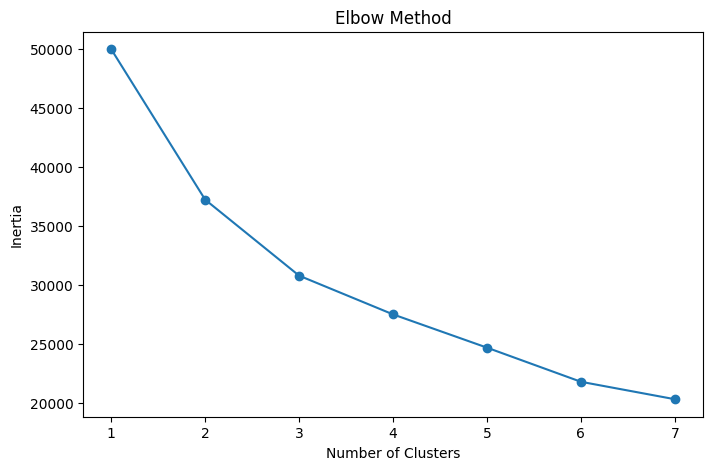

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
model_df["segment"] = kmeans.fit_predict(scaled_features)

print("Clustering complete ✅")
model_df["segment"].value_counts()

Clustering complete ✅


segment
2    3622
1    3102
3    1799
0    1477
Name: count, dtype: int64

In [15]:
segment_summary = model_df.groupby("segment")[segmentation_features].mean()
display(segment_summary)

,total_trips,avg_fare,total_spent,recency_days,tenure_days
segment,,,,,
0,23.695328,15.738858,371.492255,11.983751,359.943805
1,23.660864,15.857455,373.716212,130.852998,367.745648
2,16.777195,15.075986,251.866911,130.478465,366.566538
3,17.142301,14.976119,255.716070,17.154530,355.593107


In [16]:
segment_labels = {
    0: "Power Users",
    1: "At Risk Riders",
    2: "Stable Riders",
    3: "New / Low Engagement"
}

model_df["segment_name"] = model_df["segment"].map(segment_labels)

model_df[["user_id", "segment", "segment_name"]].head()

,user_id,segment,segment_name
0,R00000,0,Power Users
1,R00001,3,New / Low Engagement
2,R00002,1,At Risk Riders
3,R00003,3,New / Low Engagement
4,R00004,2,Stable Riders


In [18]:
import joblib

joblib.dump(kmeans, "../models/segment_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']